<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Импорт-библиотек" data-toc-modified-id="Импорт-библиотек-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Импорт библиотек</a></span></li><li><span><a href="#Пользовательские-функции" data-toc-modified-id="Пользовательские-функции-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Пользовательские функции</a></span></li><li><span><a href="#Предобработка" data-toc-modified-id="Предобработка-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Предобработка</a></span><ul class="toc-item"><li><span><a href="#Итог-предобработки" data-toc-modified-id="Итог-предобработки-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Итог предобработки</a></span></li></ul></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Анализ</a></span><ul class="toc-item"><li><span><a href="#Промежуточный-вывод" data-toc-modified-id="Промежуточный-вывод-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Промежуточный вывод</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Обучение-простых-моделей" data-toc-modified-id="Обучение-простых-моделей-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Обучение простых моделей</a></span></li><li><span><a href="#Обучение-модели-CatBoost" data-toc-modified-id="Обучение-модели-CatBoost-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Обучение модели CatBoost</a></span></li><li><span><a href="#Выбор-лучшей-модели" data-toc-modified-id="Выбор-лучшей-модели-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Выбор лучшей модели</a></span></li><li><span><a href="#Промежуточный-вывод" data-toc-modified-id="Промежуточный-вывод-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Промежуточный вывод</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Вывод</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Импорт библиотек

In [1]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import phik
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score, recall_score, accuracy_score, \
                            r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, \
                            make_scorer

from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from numpy.random import RandomState
from numpy import mean
from numpy import std

import optuna
from optuna_integration import CatBoostPruningCallback

import functools

# загружаем класс pipeline
from imblearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, \
    							  MinMaxScaler, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

# загружаем нужные модели
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from catboost import CatBoostRegressor, Pool, cv
from lightgbm import LGBMRegressor

# загружаем методы отбора признаков
from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import f_classif, mutual_info_classif
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler


In [2]:
RANDOM_STATE= 57
state = RandomState(57)
TEST_SIZE= 0.1
plt.rcParams["figure.figsize"] = (12,6)

## Пользовательские функции

In [3]:
def df_hist(df, bins=20, id=0, col=[]):

    # Удаление столбца id из датафрейма для создания графиков
    if id:
        df = df.drop(columns=['id'])
    
    if col:
        df = df[col]

    # Определение целочисленных столбцов 
    count_col = df.select_dtypes('number')
    count_col = count_col.columns[count_col.nunique() < 11]

    # Создание гистограммы и boxplot для непрерывных данных
    for col in df.select_dtypes('number').drop(columns=count_col):
        fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
        df[col].hist(bins=bins, ax=ax1)
        ax1.set_title(f'Гистограмма по столбцу "{col}"')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Количество')
        df.boxplot(column=col, ax=ax2, vert=False)
        ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax2.set_title(f'Ящик с усами по столбцу "{col}"')
        plt.xlabel(col)
        plt.show();

    # Создание countplot для целочесленных данных
    for col in df[count_col]:
        sns.countplot(data=df, x=col)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

    # Создание countplot для категориальных данных
    for col in df.select_dtypes('object'):
        sns.countplot(data=df, x=col)
        if df[col].nunique() > 3:
            plt.xticks(rotation=90)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

In [4]:
def df_info(df):
	if isinstance(df, dict):
		for key, value in df.items():
			print(key)
			value.info()
			display(value.head(5))
			print('----------------------------------------------------')
			print('\n')
	else:
		df.info()
		display(df.head(5))
		print('----------------------------------------------------')
    

In [5]:
def df_pred(df):
	if isinstance(df, dict):
		for key, value in df.items():
			print(key)
			print('Удалено явных дубликатов', value.duplicated().sum())
			df[key] = df[key].drop_duplicates()
			print('Максимум пропусков', value.isna().sum().max())
			print('----------------------------------------------------')
			print('\n')
	else: 
		print('Удалено явных дубликатов', df.duplicated().sum())
		df = df.drop_duplicates()
		print('Максимум пропусков', df.isna().sum().max())

## Предобработка

In [6]:
try:
    taxi = pd.read_csv('taxi.csv', 
                        index_col=[0],
                        parse_dates=[0],
                        encoding='cp1251'
                        ).sort_index()
except:
    taxi = pd.read_csv('/datasets/taxi.csv', 
                        index_col=[0],
                        parse_dates=[0],
                        encoding='cp1251'
                        ).sort_index()

In [7]:
df_info(taxi)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


----------------------------------------------------


In [8]:
taxi = taxi.resample('1H').sum()
df_info(taxi)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


----------------------------------------------------


Создание дополнительных признаков

In [9]:
# создаём списки с названиями признаков
ohe_columns = ['hour', 'dayofweek']
num_columns = ['rolling_mean']
cat_columns = ohe_columns

In [10]:
taxi['hour'] = taxi.index.hour
taxi['dayofweek'] = taxi.index.dayofweek

for i in range(24):
    taxi[f'lag_{i+1}'] = taxi['num_orders'].shift(i+1)
    num_columns.append(f'lag_{i+1}')

taxi['lag_168'] = taxi['num_orders'].shift(168)
num_columns.append('lag_168')

taxi['rolling_mean'] = taxi['num_orders'].shift().rolling(24).mean()
taxi.fillna(0, inplace=True)

In [11]:
taxi

,num_orders,hour,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_168,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2018-03-01 01:00:00,85,1,3,124.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2018-03-01 02:00:00,71,2,3,85.0,124.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2018-03-01 03:00:00,66,3,3,71.0,85.0,124.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2018-03-01 04:00:00,43,4,3,66.0,71.0,85.0,124.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 19:00:00,136,19,4,207.0,217.0,197.0,116.0,133.0,166.0,136.0,...,230.0,194.0,276.0,246.0,158.0,198.0,142.0,72.0,113.0,164.875000
2018-08-31 20:00:00,154,20,4,136.0,207.0,217.0,197.0,116.0,133.0,166.0,...,99.0,230.0,194.0,276.0,246.0,158.0,198.0,142.0,179.0,167.541667
2018-08-31 21:00:00,159,21,4,154.0,136.0,207.0,217.0,197.0,116.0,133.0,...,268.0,99.0,230.0,194.0,276.0,246.0,158.0,198.0,166.0,168.041667


### Итог предобработки

Данные примедены к промежуткам по 1 часу. Добвлены новые признаки: количество заказов за предыдущие дни и скользящее среднее за 7 дней

## Анализ

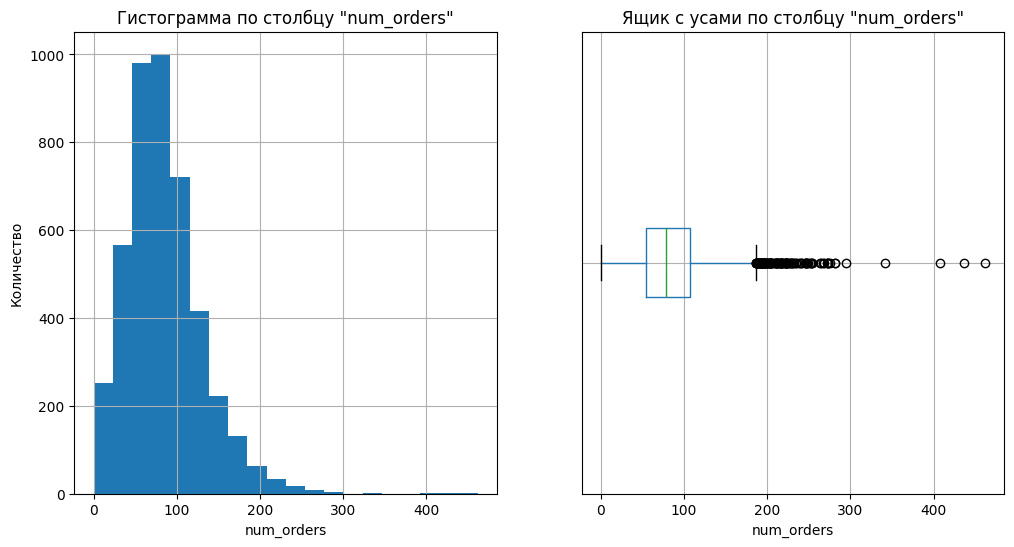

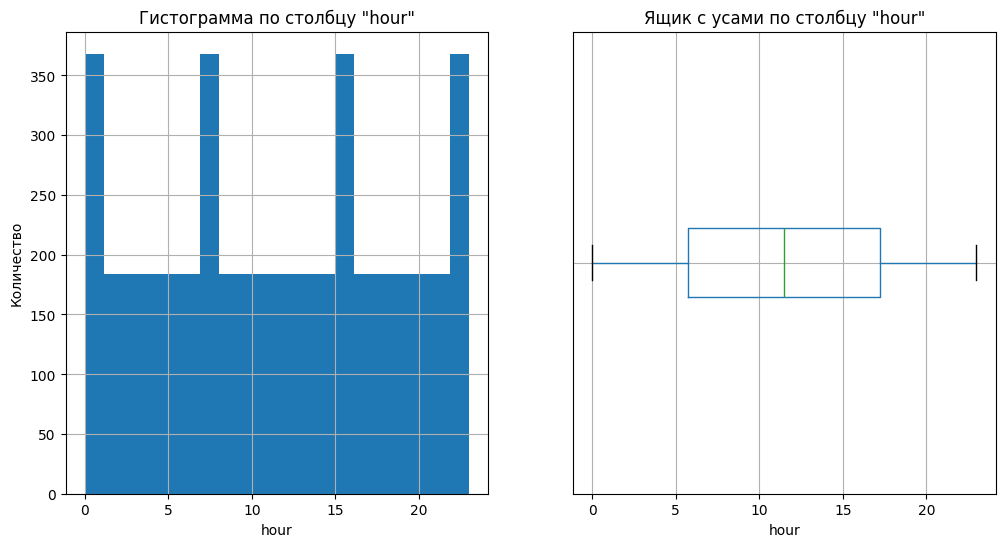

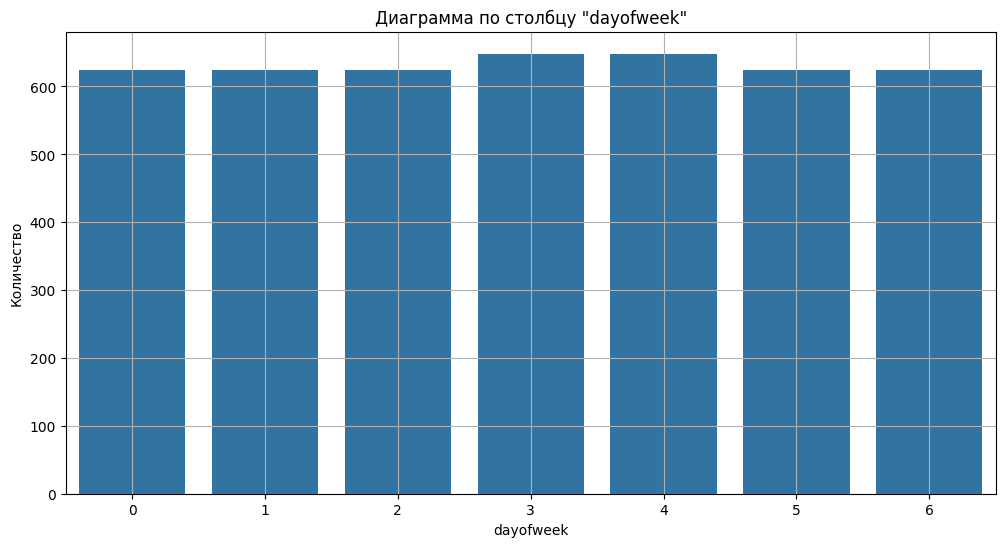

In [12]:
df_hist(taxi, col=['num_orders', 'hour', 'dayofweek'])

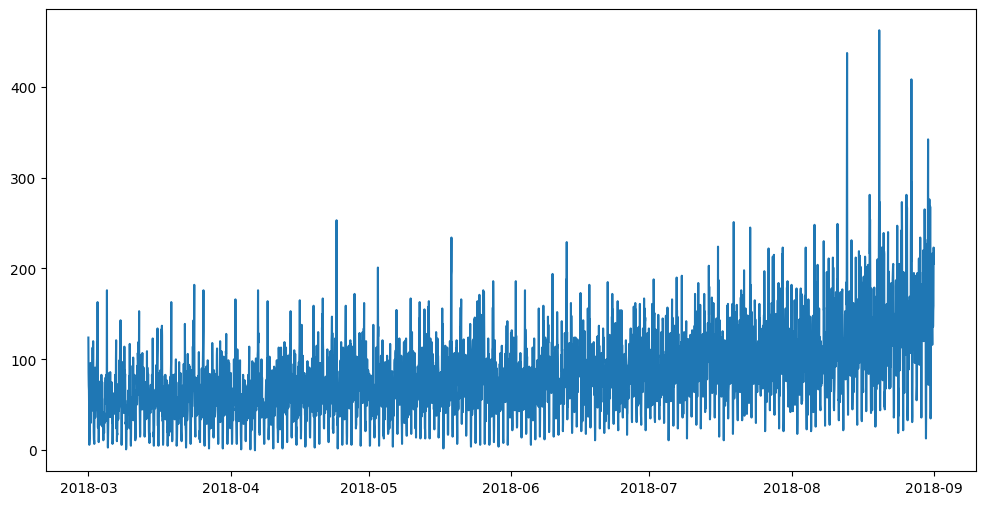

In [13]:
plt.plot(taxi.index, taxi['num_orders'])
plt.show()

In [14]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 29 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_orders    4416 non-null   int64  
 1   hour          4416 non-null   int64  
 2   dayofweek     4416 non-null   int64  
 3   lag_1         4416 non-null   float64
 4   lag_2         4416 non-null   float64
 5   lag_3         4416 non-null   float64
 6   lag_4         4416 non-null   float64
 7   lag_5         4416 non-null   float64
 8   lag_6         4416 non-null   float64
 9   lag_7         4416 non-null   float64
 10  lag_8         4416 non-null   float64
 11  lag_9         4416 non-null   float64
 12  lag_10        4416 non-null   float64
 13  lag_11        4416 non-null   float64
 14  lag_12        4416 non-null   float64
 15  lag_13        4416 non-null   float64
 16  lag_14        4416 non-null   float64
 17  lag_15        4416 non-null

In [15]:
decomposed = seasonal_decompose(taxi['num_orders'].resample('1D').sum()) 

<Axes: xlabel='datetime'>

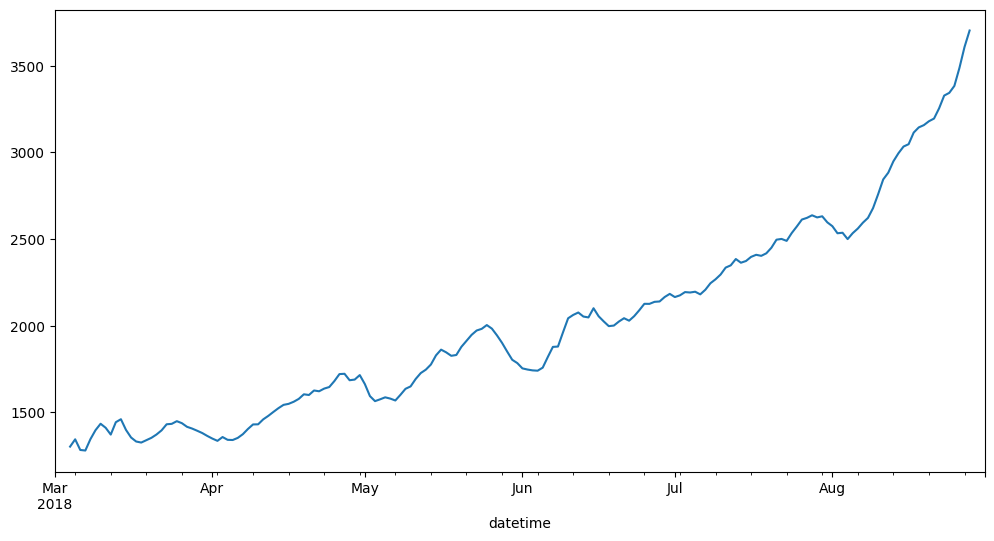

In [16]:
decomposed.trend[:].plot(ax=plt.gca())

<Axes: xlabel='datetime'>

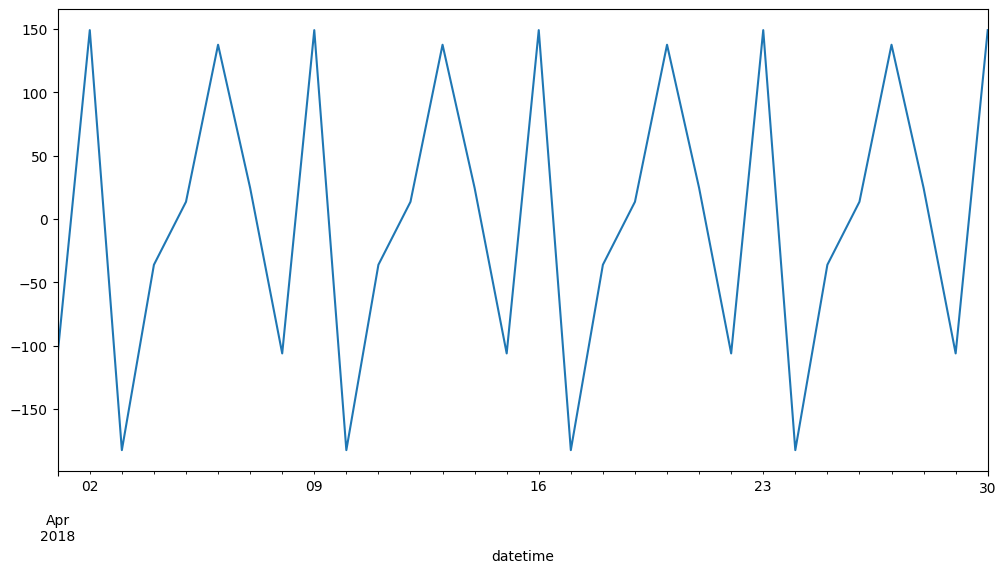

In [17]:
decomposed.seasonal['04-2018':'04-2018'].plot(ax=plt.gca())

<Axes: xlabel='datetime'>

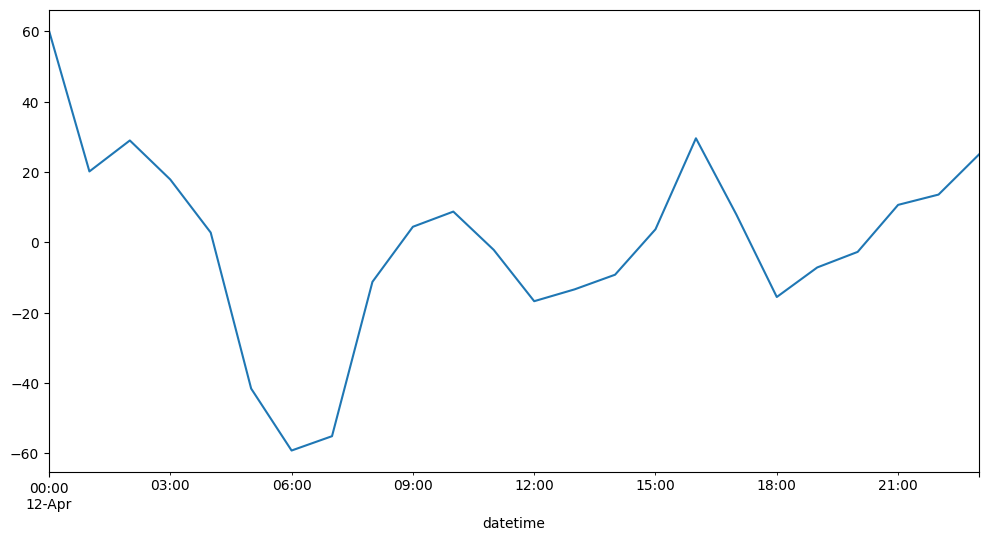

In [18]:
decomposed_hours = seasonal_decompose(taxi['num_orders'])
decomposed_hours.seasonal['04-12-2018':'04-12-2018'].plot(ax=plt.gca())

<Axes: xlabel='datetime'>

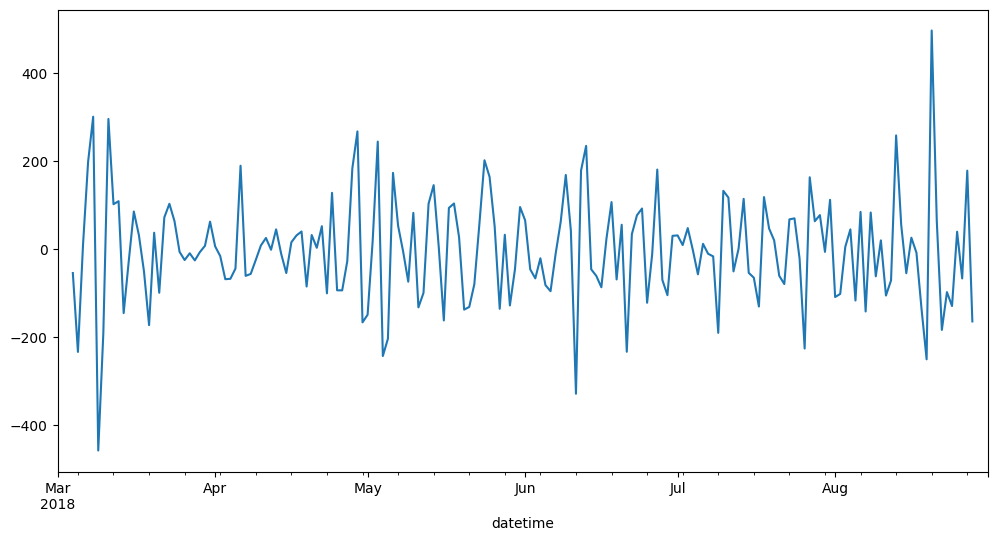

In [19]:
decomposed.resid[:].plot(ax=plt.gca())

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


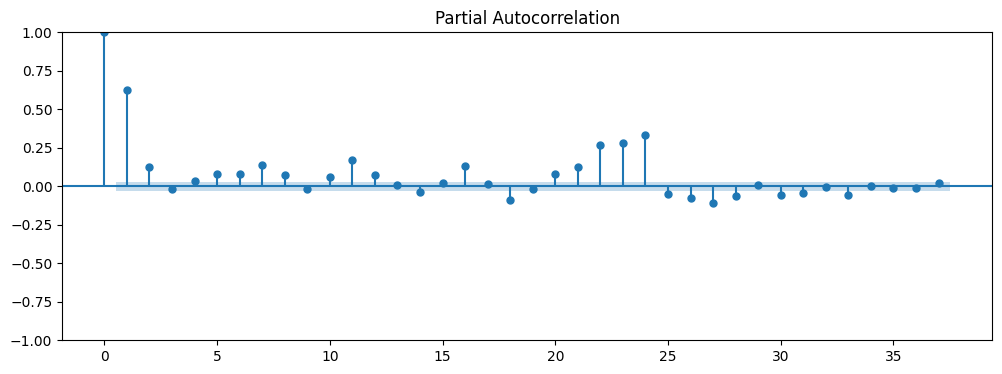

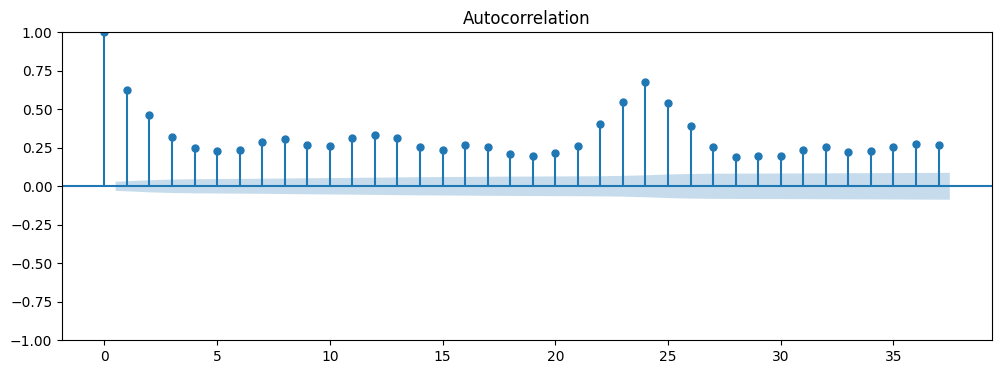

In [20]:
plot_pacf(taxi['num_orders'], alpha=0.05).set_size_inches(12, 4)
plt.show()

plot_acf(taxi['num_orders'], alpha=0.05).set_size_inches(12, 4)
plt.show()

### Промежуточный вывод

Согласно графикам видна четкая линия тренда на повыешние количества заказов. Также имеется четкая сезонность, свзяанная с падением спроса во вторник, среду и воскресенье. Также имеется суточная сезонность связанная с пониженным спросом в промежутке от 3 до 8 часов. При этом среднее количество заказов по месяцам и дням недели в течение года почти не отличаются

## Обучение

### Подготовка

In [21]:
X = taxi.drop(columns=['num_orders'])
y = taxi['num_orders']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = TEST_SIZE, 
                                                    shuffle=False                                         
                                                    )

In [22]:
ohe_pipe = Pipeline(
    [
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

param_grid = [
    {
        'models': [LinearRegression()]  
    },
    
	{
        'models': [Ridge()],
        'models__alpha' : np.arange(0.1, 2.1, 0.1)
    },
    
	{
        'models': [Lasso()],
        'models__alpha' : np.arange(0.1, 2.1, 0.1)
    },
    	
    {
        'models': [KNeighborsRegressor()],
        'models__n_neighbors': range(2,30),
    },

    {
        'models': [SVR()],
        'models__C': range(1,10),
        'models__kernel': ['linear', 'rbf', 'sigmoid'], 
    }
]

In [23]:
tscv = TimeSeriesSplit(n_splits=5)

### Обучение простых моделей

In [24]:
randomized_search = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    refit='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

In [25]:
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика RMSE лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['hour', 'dayofweek']),
                                                 ('num', StandardScaler(),
                                                  ['rolling_mean', 'lag_1',
                                                   'lag_2', 'lag_3', 'lag_4',
                                                   'lag_5', 'lag_6', 'lag_7',
                                                   'lag_

In [26]:
base_score = -randomized_search.best_score_
base_model = randomized_search.best_estimator_

### Обучение модели CatBoost

In [27]:
cv_dataset = Pool(data=X_train,
                  label=y_train,
                  cat_features=cat_columns
                  )

In [28]:
def objective(trial, X, y):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 1500, step=100),
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 15, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 2),
        "random_strength": trial.suggest_float("random_strength", 1e-5, 10, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "border_count": trial.suggest_int("border_count", 32, 224, step=32),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "boosting_type": "Ordered",
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "verbose": False,
        "random_seed": RANDOM_STATE,
        "early_stopping_rounds": 50
    }
    
    # Настройка TimeSeriesSplit
    n_splits = 5
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=0)
    
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = CatBoostRegressor(**params,
                                  cat_features=cat_columns)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            verbose=False,
            early_stopping_rounds=params["early_stopping_rounds"]
        )
        y_pred = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        cv_scores.append(rmse)
    
    return np.mean(cv_scores)

In [29]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
objective_with_data = functools.partial(objective, X=X_train, y=y_train)
study.optimize(objective_with_data, n_trials=50, show_progress_bar=True)

catboost_best_params = study.best_params
catboost_best_value = study.best_value

print(f"Лучшие параметры: {catboost_best_params}")
print(f"Лучшее значение RMSE: {catboost_best_value:.4f}")

RMSE_mean = catboost_best_value


[I 2026-05-25 20:06:41,531] A new study created in memory with name: no-name-4cb98c16-eaf5-46b7-9c9a-61ccf01a303d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-25 20:07:42,723] Trial 0 finished with value: 22.428294087643756 and parameters: {'iterations': 500, 'depth': 4, 'learning_rate': 0.022777942883049962, 'l2_leaf_reg': 2.320111278351746, 'bagging_temperature': 1.131911781523011, 'random_strength': 0.01863726681483545, 'min_child_samples': 42, 'border_count': 224, 'subsample': 0.8088363011374708, 'colsample_bylevel': 0.7123436306941425}. Best is trial 0 with value: 22.428294087643756.
[I 2026-05-25 20:09:25,683] Trial 1 finished with value: 22.661851263390663 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.02358622194227635, 'l2_leaf_reg': 4.838210937113613, 'bagging_temperature': 0.4283070717509063, 'random_strength': 0.004840765878612573, 'min_child_samples': 26, 'border_count': 32, 'subsample': 0.9709151579208837, 'colsample_bylevel': 0.5804934221712661}. Best is trial 0 with value: 22.428294087643756.
[I 2026-05-25 20:09:37,267] Trial 2 finished with value: 22.37629210370236 and parameters: {'iterations'

In [30]:
fixed_params = {
    "boosting_type": "Ordered",
	"loss_function": "RMSE",
	"eval_metric": "RMSE",
	"verbose": False,
	"random_seed": RANDOM_STATE,
	"early_stopping_rounds": 50
}

params = {'iterations': 1100, 
          'depth': 8, 
          'learning_rate': 0.027338933671135563, 
          'l2_leaf_reg': 11.295253210661084, 
          'bagging_temperature': 1.9858618985593235, 
          'random_strength': 8.486210871761187, 
          'min_child_samples': 18, 
          'border_count': 96, 
          'subsample': 0.7340161879298177, 
          'colsample_bylevel': 0.6108825428125747}
try:
	best_params = {**catboost_best_params, **fixed_params}
except:
	best_params = {**params, **fixed_params}
	RMSE_mean = 24.8919

In [31]:
catboost_model = CatBoostRegressor(**best_params,
                                   cat_features=cat_columns)
catboost_score = RMSE_mean

### Выбор лучшей модели

In [43]:
models_score = [base_score, catboost_score]
models = [base_model, catboost_model]

if base_score < catboost_score:
    best_model = base_model
    best_score = base_score
else: 
    best_model = catboost_model
    best_score = catboost_score
    
print(f'Лучшая модель по результатам кроссвалидации {best_model}')
print(f'С метрикой RMSE на CV {best_score:.4f}')

Лучшая модель по результатам кроссвалидации <catboost.core.CatBoostRegressor object at 0x000002AF9777DBE0>
С метрикой RMSE на CV 22.0968


### Промежуточный вывод

Лучшей модель по результатам кросс-валидации оказалась модель CatBoost с метрикой RMSE = 24,89

## Тестирование

In [33]:
best_model.fit(X_train, y_train,
               verbose=False)

In [42]:
preds = best_model.predict(X_test)
print(f'RMSE на тестовой выборке {root_mean_squared_error(y_test, preds):.4f}')

RMSE на тестовой выборке 39.5696


### Проверка модели на адекватность

Возьмем за предсказанные значения остающие на 24 и 168 часов и посчитаем метрику RMSE

In [41]:
print(f'Метрика RMSE при предсказании отсающим значением на 24: {root_mean_squared_error(y_test[24:], y_test.shift(24)[24:]):.4f}')

Метрика RMSE при предсказании отсающим значением на 24: 56.2417


In [ ]:
print(f'Метрика RMSE при предсказании отсающим значением на 168: {root_mean_squared_error(y_test[168:], y_test.shift(168)[168:]):.4f}')

Метрика RMSE при предсказании отсающим значением на 168: 42.03


По данным результатам видно, что обученная модель предсказывает значения лучше эвристического подхода с отсающими значениями, но не намного. Для улучшения может потребоваться добавление признаков и и зменение моделей

## Вывод

В результате работы была обучена модель CatBoost с метрикой RMSE на тестовых данных - 39,57. Данное значение метрики не превышает целевого значения по ТЗ - 48.

В итоге подготовки датасета были добавлены новые признаки: как категориальные (месяц, день недели), так и количественные (скользящее среднее и остающие значения)

В ходе работы были испробованы базовые модели LinearRegressor, KNN, DecisionTree, которые показали хороший результат, но CatBoost оказался лучше.

Также для каждой модели перебирались параметры с помощью GridSearchCV и с помощью optuna.